***Лабораторная работа №1. Освоение базового ML-пайплайна на табличных данных***



**Задачи**
- Провести разведочный анализ данных (EDA) с использованием визуализации
- Выполнить предобработку: обработка пропусков, коррекция выбросов, кодирование категориальных - - признаков, масштабирование
- Отобрать релевантные признаки и обосновать выбор. Feature engineering 
- Разделить данные на обучающую, валидационную и тестовую выборки без утечки данных
- Обучить Linear Regression для задачи регрессии (спрогнозируйте CGPA успеваемость студента на основе его режима занятий и сна)
- Обучить Logistic Regression для задачи классификации (определите, подвержен ли учащийся риску развития депрессии (столбец Depression), исходя из его образа жизни и уровня стресса).
- Поэкспериментируйте со значением шага обучения (learning rate) и числом эпох
- Для логистической регрессии доказать отсутствие переобучения
- Оценить качество моделей с использованием соответствующих метрик 
- Сделать выводы о качестве моделей и влиянии этапов предобработки


Подключаем нужные библиотеки для ЛР

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Читаем датасет

In [2]:
data_set = pd.read_csv('student_lifestyle_100k.csv')

Смотрим размеры датасета и его начало

In [3]:
print("Размер датасета:", data_set.shape)
data_set.head()

Размер датасета: (100000, 11)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Просматриваем базовую информацию о датасете 

In [4]:
print("Базовая информация о датасете: ")
data_set.info()

Базовая информация о датасете: 
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Проверяем наличие пропусков в датасете

In [5]:
print("Проверка пропусков:")
print(data_set.isnull().sum())

Проверка пропусков:
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64


Проверяем наличие дубликатов 

In [6]:
print("Проверка дубликатов:")
print(data_set.duplicated().sum())

Проверка дубликатов:
0


Проверка данных дата сета на логику 


In [7]:
print("\nПроверка столбцов на логику: ")
errors = {}

invalid_age = data_set[(data_set['Age'] < 0) | (data_set['Age'] > 100)]
errors['Age'] = len(invalid_age)

invalid_cgpa = data_set[(data_set['CGPA'] < 0) | (data_set['CGPA'] > 4.0)]
errors['CGPA'] = len(invalid_cgpa)

invalid_sleep = data_set[(data_set['Sleep_Duration'] < 0) | (data_set['Sleep_Duration'] > 24)]
errors['Sleep_Duration'] = len(invalid_sleep)

invalid_study = data_set[(data_set['Study_Hours'] < 0) | (data_set['Study_Hours'] > 24)]
errors['Study_Hours'] = len(invalid_study)

invalid_social = data_set[(data_set['Social_Media_Hours'] < 0) | (data_set['Social_Media_Hours'] > 24)]
errors['Social_Media_Hours'] = len(invalid_social)

invalid_phys = data_set[(data_set['Physical_Activity'] < 0)]
errors['Physical_Activity'] = len(invalid_phys)
invalid_stress = data_set[(data_set['Stress_Level'] < 1) | (data_set['Stress_Level'] > 10)]

errors['Stress_Level'] = len(invalid_stress)

for col, count in errors.items():
    status = "True" if count == 0 else "False"
    print(f"  {col:20}: {status}")

if sum(errors.values()) == 0:
    print("Все значения находятся в допустимых пределах")


Проверка столбцов на логику: 
  Age                 : True
  CGPA                : True
  Sleep_Duration      : True
  Study_Hours         : True
  Social_Media_Hours  : True
  Physical_Activity   : True
  Stress_Level        : True
Все значения находятся в допустимых пределах


Проверка, что у человека 24 часа в сутках

In [8]:
data_set['total_hour'] = data_set['Sleep_Duration'] + data_set['Social_Media_Hours'] + data_set['Study_Hours']
over_24 = data_set[(data_set['total_hour']>24)]
print(len(over_24))

78


Змечаем, что есть такие люди и их надо удалить

In [9]:
data_set = data_set[(data_set['total_hour']<=24)]
print(len(data_set))
data_set.drop(columns=['total_hour'],inplace=True)

99922


## Построение графиков и их анализ 

Настройка отображения графиков 

In [10]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

Строим Графики распределения численных признаков 

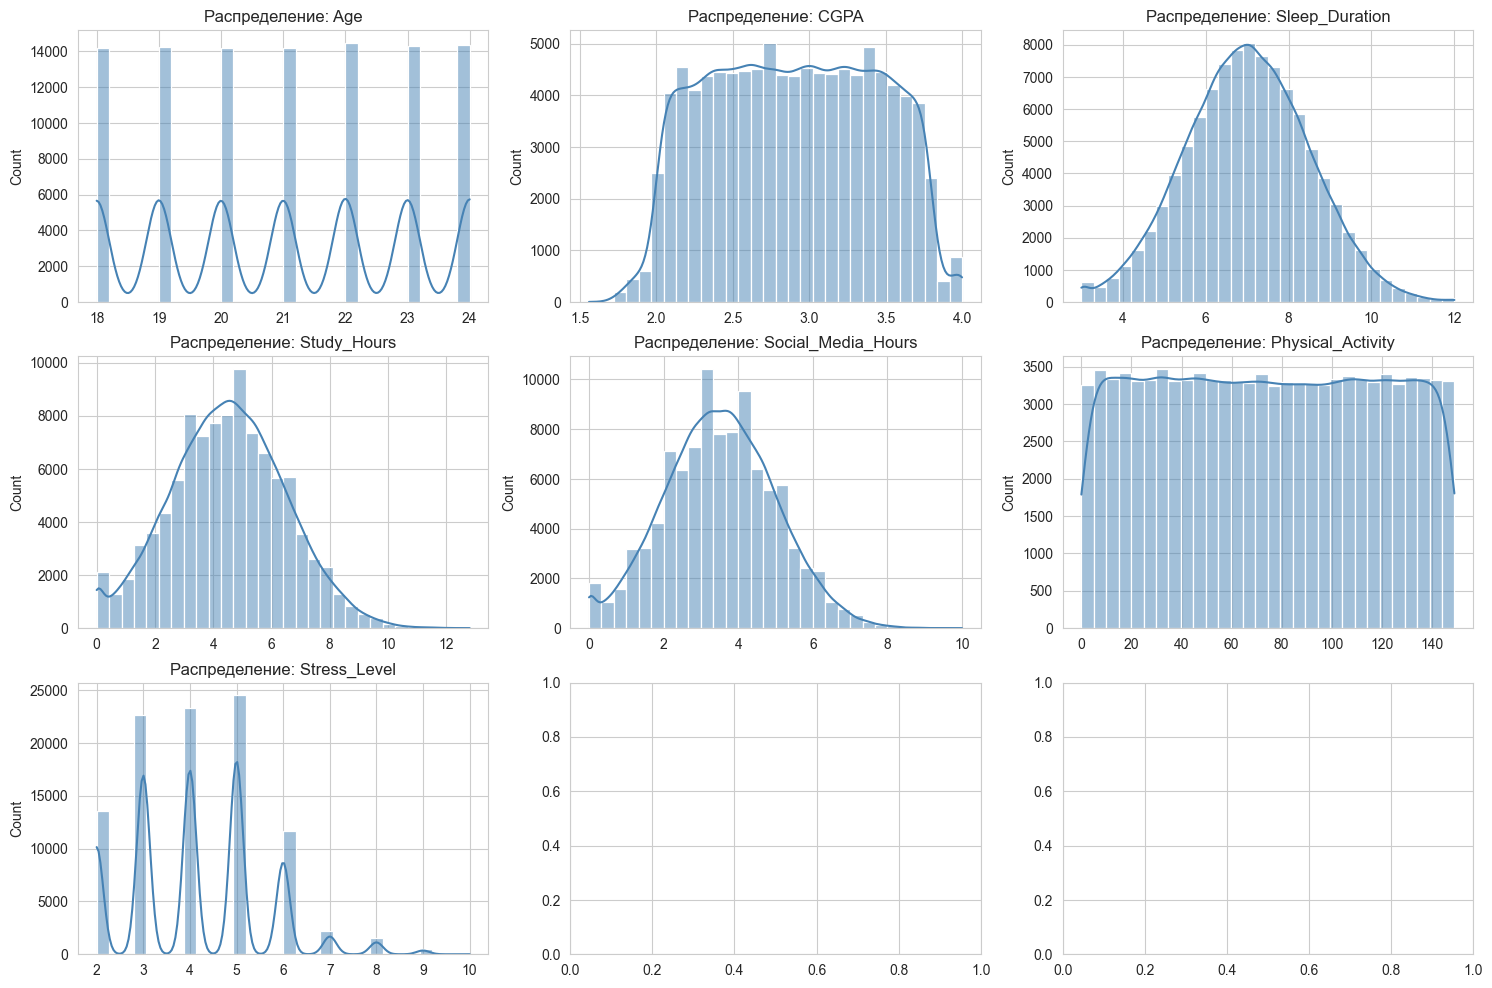

In [11]:
num_cols = ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 
            'Physical_Activity', 'Stress_Level']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data_set[col].dropna(), bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel('')
plt.show()

Строим график распределения по полу

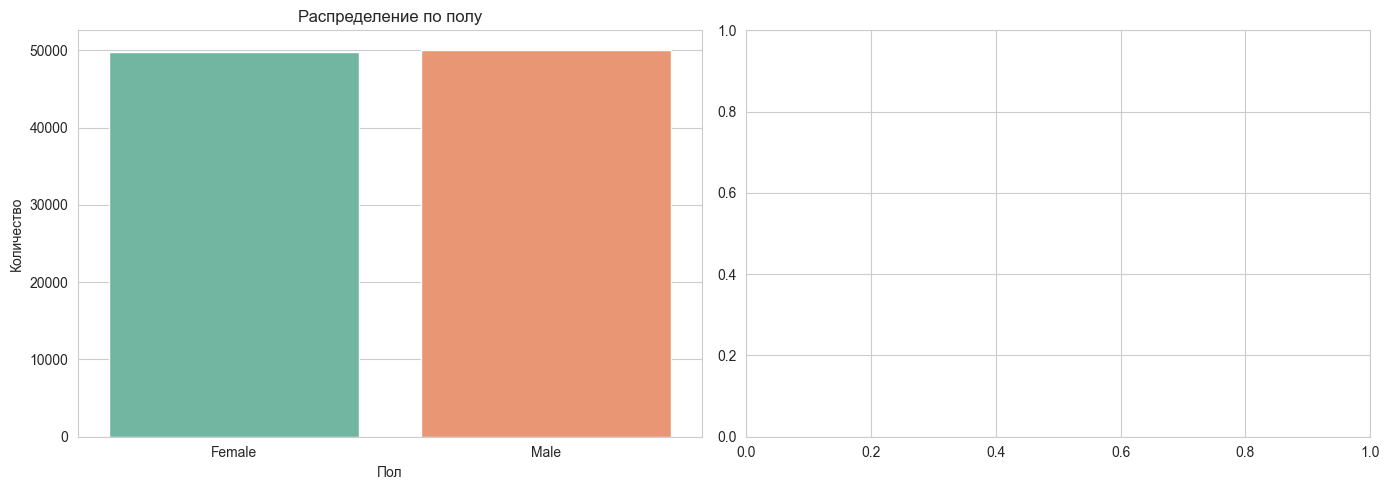

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=data_set, x='Gender', hue='Gender', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Распределение по полу')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Количество')
plt.tight_layout()
plt.show()

Строим матрицу корреляции признаков 

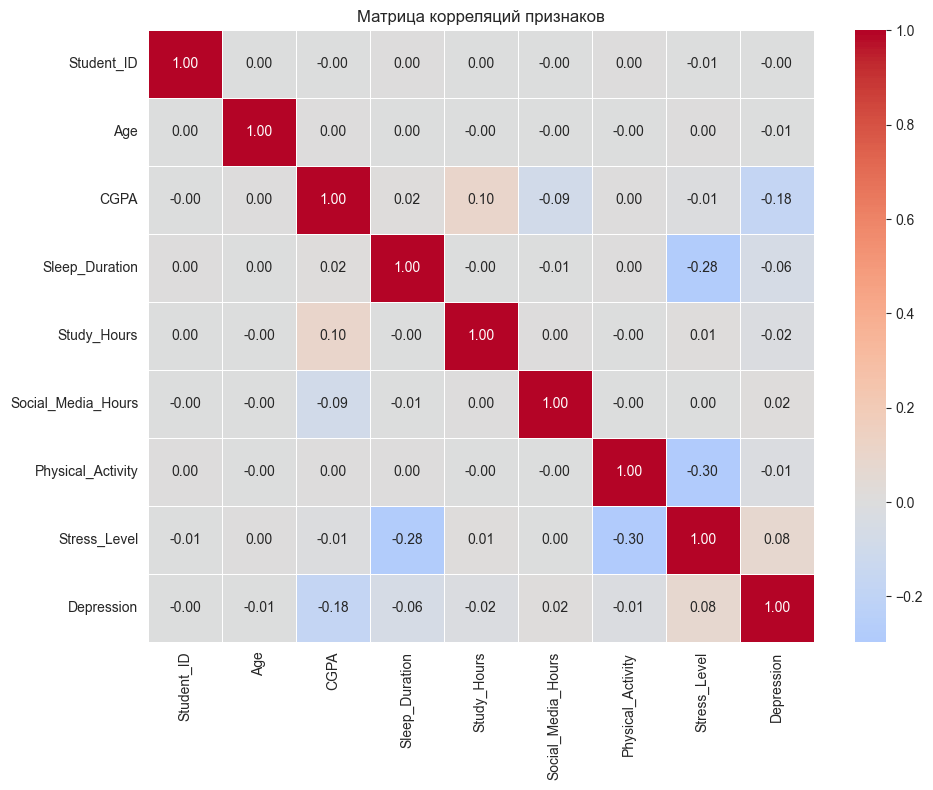

In [13]:
df_corr = data_set.copy()
df_corr['Depression'] = df_corr['Depression'].astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', 
            fmt='.2f', linewidths=0.5, center=0)
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

Строим график Уровня стресса и дипрессии

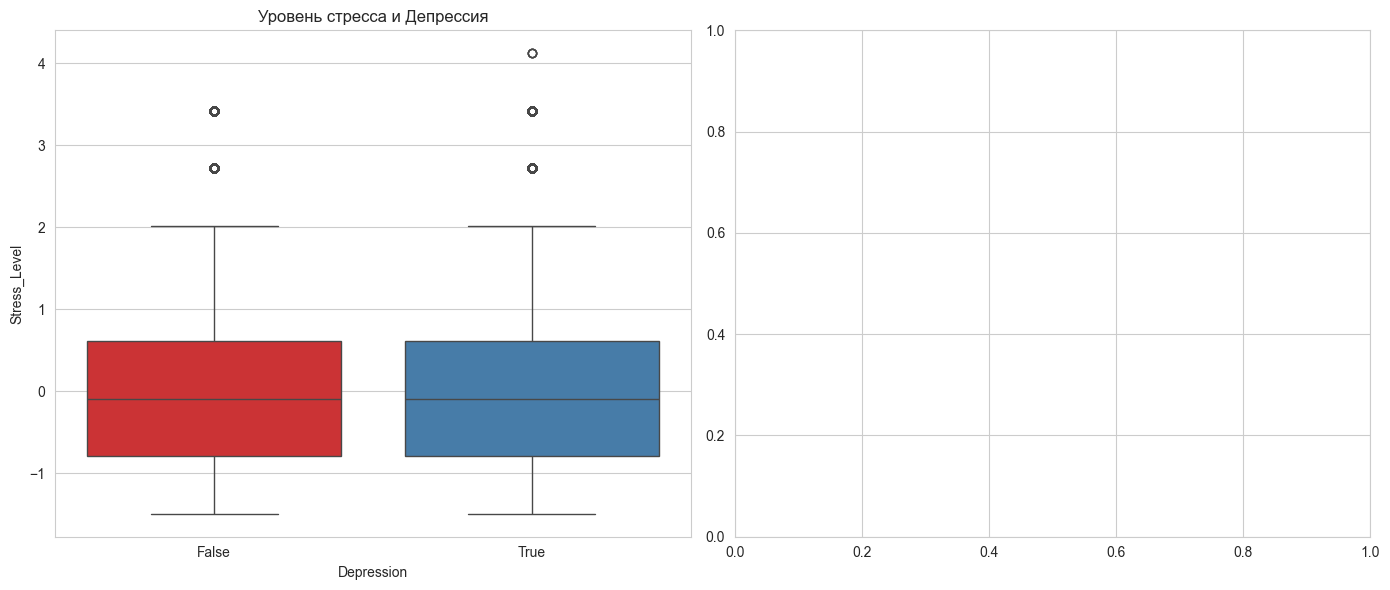

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=data_set, x='Depression', y='Stress_Level', hue='Depression', ax=axes[0], palette='Set1', legend=False)
axes[0].set_title('Уровень стресса и Депрессия')
plt.tight_layout()
plt.show()

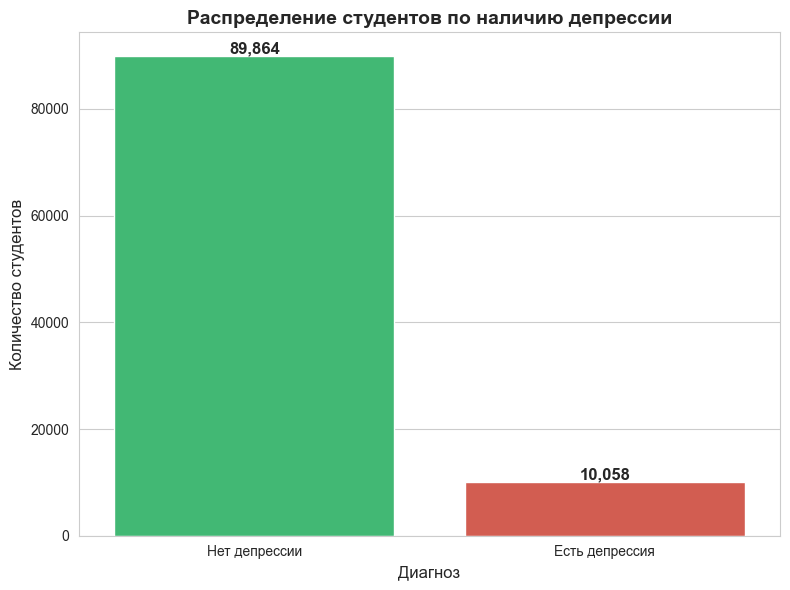

In [ ]:
depression_counts = data_set['Depression'].value_counts()
depression_percent = data_set['Depression'].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 6))
sns.countplot(data=data_set, x='Depression', hue='Depression', 
              palette=['#2ecc71', '#e74c3c'], legend=False)

plt.title('Распределение студентов по наличию депрессии', fontsize=14, fontweight='bold')
plt.xlabel('Диагноз', fontsize=12)
plt.ylabel('Количество студентов', fontsize=12)
plt.xticks([0, 1], ['Нет депрессии', 'Есть депрессия'])

for i, count in enumerate(depression_counts):# добавление значений на столбцы
    plt.text(i, count + 500, f'{count:,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Кодироваение категорий 

In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

Кодируем гендер:

In [16]:
le_gender = LabelEncoder()
data_set['Gender_encoded'] = le_gender.fit_transform(data_set['Gender'])
print(dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print(data_set[['Gender', 'Gender_encoded']].head())

{'Female': np.int64(0), 'Male': np.int64(1)}
   Gender  Gender_encoded
0  Female               0
1    Male               1
2    Male               1
3    Male               1
4    Male               1


Кодируем Department (имеет много вариантов значнений для этого подойдет One-Hot Encoding)

In [17]:
data_set = data_set.drop(columns=[col for col in data_set.columns if col.startswith('Department_')], errors='ignore')# дропаем старые закодированные столбцы
od = OneHotEncoder(sparse_output=False, drop='first')
dp_encod = od.fit_transform(data_set[['Department']]) # категории в числа 
dp_df = pd.DataFrame(dp_encod, 
                      columns=[f'Department_{i}' for i in od.categories_[0][1:]], 
                      index=data_set.index)#новые имена дл столбцов 

data_set = pd.concat([data_set, dp_df], axis=1) # присоединяем 
print(data_set.head())

   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science 3.500           7.300        3.300   
1        1002   20    Male  Engineering 2.720           5.500        7.200   
2        1003   20    Male      Medical 3.010           5.400        2.300   
3        1004   21    Male  Engineering 3.630           8.100        2.000   
4        1005   19    Male         Arts 3.140           6.800        2.600   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  \
0               3.400                114             5       False   
1               6.000                142             2       False   
2               1.800                137             3       False   
3               4.600                130             3       False   
4               4.300                  4             6       False   

   Gender_encoded  Department_Business  Department_Engineering  \
0               0                0.000      

Кодируем признак дипрессии 

In [18]:
data_set['Depression_encoded'] = data_set['Depression'].astype(int) #приводим к инту
print(data_set.head())

   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science 3.500           7.300        3.300   
1        1002   20    Male  Engineering 2.720           5.500        7.200   
2        1003   20    Male      Medical 3.010           5.400        2.300   
3        1004   21    Male  Engineering 3.630           8.100        2.000   
4        1005   19    Male         Arts 3.140           6.800        2.600   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  \
0               3.400                114             5       False   
1               6.000                142             2       False   
2               1.800                137             3       False   
3               4.600                130             3       False   
4               4.300                  4             6       False   

   Gender_encoded  Department_Business  Department_Engineering  \
0               0                0.000      

Маштабируем числовые признаки 


In [19]:
num_features = ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 
                'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
scaler = StandardScaler()
data_set[num_features] = scaler.fit_transform(data_set[num_features])# приводим все признаки к одному порядку (сандартному виду)
print(data_set.head())

   Student_ID    Age  Gender   Department   CGPA  Sleep_Duration  Study_Hours  \
0        1001  0.495  Female      Science  1.131           0.204       -0.611   
1        1002 -0.504    Male  Engineering -0.335          -0.998        1.366   
2        1003 -0.504    Male      Medical  0.210          -1.065       -1.118   
3        1004 -0.004    Male  Engineering  1.375           0.739       -1.271   
4        1005 -1.004    Male         Arts  0.454          -0.130       -0.966   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  \
0              -0.068              0.914         0.610       False   
1               1.683              1.560        -1.497       False   
2              -1.146              1.445        -0.794       False   
3               0.740              1.283        -0.794       False   
4               0.538             -1.622         1.312       False   

   Gender_encoded  Department_Business  Department_Engineering  \
0               0         

 ### Feature Engineering

In [20]:
data_set['Study_Efficiency'] = data_set['CGPA'] / (data_set['Study_Hours'] + 0.1)
data_set['Sleep_Study_Ratio'] = data_set['Sleep_Duration'] / (data_set['Study_Hours'] + 0.1)
data_set['Total_Activity'] = (data_set['Study_Hours'] + data_set['Social_Media_Hours'] + data_set['Physical_Activity'])/10
data_set['Work_Life_Balance'] = data_set['Sleep_Duration'] / (data_set['Study_Hours'] + data_set['Social_Media_Hours'] + 0.1)
data_set['Stress_per_Study'] = data_set['Stress_Level'] / (data_set['Study_Hours'] + 0.1)
data_set['Is_Active'] = (data_set['Physical_Activity'] > 100).astype(int)
print(data_set)

       Student_ID    Age  Gender   Department   CGPA  Sleep_Duration  \
0            1001  0.495  Female      Science  1.131           0.204   
1            1002 -0.504    Male  Engineering -0.335          -0.998   
2            1003 -0.504    Male      Medical  0.210          -1.065   
3            1004 -0.004    Male  Engineering  1.375           0.739   
4            1005 -1.004    Male         Arts  0.454          -0.130   
...           ...    ...     ...          ...    ...             ...   
99995      100996  1.495  Female      Medical -1.650           0.004   
99996      100997  1.495    Male         Arts -1.068          -1.332   
99997      100998  1.495  Female  Engineering -1.256          -0.330   
99998      100999 -1.004    Male  Engineering  1.337          -0.597   
99999      101000  1.495  Female      Medical -1.500           0.605   

       Study_Hours  Social_Media_Hours  Physical_Activity  Stress_Level  \
0           -0.611              -0.068              0.914   

## 

### Разделение данные на обучающую, валидационную и тестовую выборки 

In [21]:
from sklearn.model_selection import train_test_split
colms = ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 
                'Physical_Activity', 'Stress_Level', 'Gender_encoded',
                'Department_Business', 'Department_Engineering', 'Department_Medical', 'Department_Science',
                'Study_Efficiency', 'Sleep_Study_Ratio', 'Total_Activity','Work_Life_Balance','Stress_per_Study','Is_Active']
X = data_set[colms]
y_reg = data_set['CGPA']  # для регрессии
y_clf = data_set['Depression_encoded']  # для классификации
X_train, X_temp, y_train, y_temp = train_test_split(X, y_reg, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf, y_temp_clf, test_size=0.5, random_state=42, stratify=y_temp_clf)

print(f"Регрессия: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")
print(f"Классификация: Train={X_train_clf.shape}, Val={X_val_clf.shape}, Test={X_test_clf.shape}")

Регрессия: Train=(69945, 17), Val=(14988, 17), Test=(14989, 17)
Классификация: Train=(69945, 17), Val=(14988, 17), Test=(14989, 17)


Базывые признаки которые влияют на модели возраст,пол.
На успеваемость влияют как количество учебных часов, так и общее физическое и ментальное состояние обучающегося. Еще на успеваемость влияет факультет(Department) на разных специальностях разное отношение к учебе где-то может быть сильно сложнее по сравнению с другими. 
На депрессию аналогично влияют данные признаки. 

### Обучение Linear Regression для CGPA

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.4f}, R2: {r2_score(y_train, y_train_pred):.4f}")
print(f"Val MSE: {mean_squared_error(y_val, y_val_pred):.4f}, R2: {r2_score(y_val, y_val_pred):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_test_pred):.4f}, R2: {r2_score(y_test, y_test_pred):.4f}")

Train MSE: 0.9674, R2: 0.0345
Val MSE: 0.9568, R2: 0.0376
Test MSE: 0.9672, R2: 0.0295


Модель работает плохо прогнозирует где-то 3%. Такой маленький процент объясняется тем, что наши гащи исходные данные мало коррелируют между собой для СGPA корреляция 0.1 с часами обучения. Попытки добавить новые данные тоже не дали результатов. 

### Логическая регрессия 

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_clf, y_train_clf)

y_train_pred = log_reg.predict(X_train_clf)
y_val_pred = log_reg.predict(X_val_clf)
y_test_pred = log_reg.predict(X_test_clf)
y_test_proba = log_reg.predict_proba(X_test_clf)[:, 1]

print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (Depression)")
print(f"Train Accuracy: {accuracy_score(y_train_clf, y_train_pred):.4f}")
print(f"Val Accuracy: {accuracy_score(y_val_clf, y_val_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_clf, y_test_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test_clf, y_test_proba):.4f}")

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (Depression)
Train Accuracy: 0.8993
Val Accuracy: 0.8994
Test Accuracy: 0.8993
Test ROC-AUC: 0.5492


У модели имеется высокая точность выявления депрессии, но это обуславливается тем, что в исходном датасете распределение 90/10, что примерно и показывает модель. Но Test ROC-AUC показывает, что модель плохо различает классы и работает чуть лучше простого угадывая.

### Эксперименты с шагом 

In [27]:
from sklearn.linear_model import SGDRegressor,SGDClassifier
learning_rates = [0.001, 0.01, 0.05, 0.1]
for lr_rate in learning_rates:
    sgd = SGDRegressor(
    learning_rate='adaptive', 
    eta0=1e-5,                 
    max_iter=5000,             
    tol=1e-4,
    random_state=42
)
    sgd.fit(X_train, y_train)
    y_pred = sgd.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    print(f"SGDRegressor lr={lr_rate}: Val MSE={mse:.4f}")

for lr_rate in learning_rates:
    sgd_clf = SGDClassifier(
    loss='log_loss',
    learning_rate='adaptive',
    eta0=1e-5,
    max_iter=5000,
    random_state=42
)
    sgd_clf.fit(X_train_clf, y_train_clf)
    acc = accuracy_score(y_val_clf, sgd_clf.predict(X_val_clf))
    print(f"SGDClassifier lr={lr_rate}: Val Accuracy={acc:.4f}")

SGDRegressor lr=0.001: Val MSE=13603757559372.6230
SGDRegressor lr=0.01: Val MSE=13603757559372.6230
SGDRegressor lr=0.05: Val MSE=13603757559372.6230
SGDRegressor lr=0.1: Val MSE=13603757559372.6230
SGDClassifier lr=0.001: Val Accuracy=0.8994
SGDClassifier lr=0.01: Val Accuracy=0.8994
SGDClassifier lr=0.05: Val Accuracy=0.8994
SGDClassifier lr=0.1: Val Accuracy=0.8994


In [28]:
train_acc = accuracy_score(y_train_clf, log_reg.predict(X_train_clf))
val_acc = accuracy_score(y_val_clf, y_val_pred)

print(f"Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}")
print(f"Разница: {abs(train_acc - val_acc):.4f}")

if abs(train_acc - val_acc) < 0.05:
    print("Переобучение отсутствует")
else:
    print("Возможно переобучение")

Train Accuracy: 0.8993, Val Accuracy: 0.8994
Разница: 0.0001
Переобучение отсутствует


В ходе данной лабораторной работы были выплнены следующие задачи :
1) разведочный анализ( просмотр данных дата сета, построение графиков, пстроение матрицы корреляции)
2) выявили слабую корреляцию междупризнаками и целевыми переменными
3) была проведен предварительный анализ данных (смотрели на логику признаков)
4) удаление некорректных данных (сумма часов >24)
5) маштабирование признаков 
6) обучение моделей 
7) эксперименты с шагами и проверка на переобучение 
Вывод по моделям: r**2 = 0.03 показывает, что модель плохо прогнозирует успеваемость обучающихся. Это можно объяснить тем, что исходные признаки слабо коррелировали между собой, для прогнозирования успеваемости мало фактов ( например можно добавить [способности ученика, интерес к предмету, качество преподавания] ). 
По логистической регрессии модель показала хорошие прогнозирование дипрессии, но это обусловлино дата сетом (90/10). Для для реальных случаев прогнозирование справляется плохо (чуть лучше угадывания).
Такое качество моделей обусловлино самим дата сетом и качеством данных, которые изначально кажутся идеальными, но во время работы оказываются плохими(слабая корреляция с целевыми признаками)

